# Restaurant Data Analysis Project
## Objective
Analyze restaurant data to identify patterns in ratings, cuisine popularity, price range, and service features like table booking and online delivery.

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

In [5]:
!pip install seaborn

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [7]:
# load csv
df = pd.read_csv("zomato.csv", encoding="latin1")

In [8]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
# Initial inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()


Shape: (9551, 21)

Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude     

In [10]:
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))


Missing values:
Cuisines                9
Restaurant Name         0
Country Code            0
City                    0
Restaurant ID           0
Address                 0
Locality                0
Longitude               0
Locality Verbose        0
Latitude                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [11]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [12]:
# Clean column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

df.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='str')

In [13]:
#Trim text and convert numbers

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

num_cols = ['longitude', 'latitude', 'price_range', 'aggregate_rating', 'votes', 'country_code']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

C:\Users\MANSI\AppData\Local\Temp\ipykernel_15420\2583815231.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [14]:
# Handle missing values and duplicates

df = df.drop_duplicates().copy()

for col in df.columns:
    if df[col].dtype.kind in 'biufc':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna('Unknown')

df.isna().sum().sum()

np.int64(0)

In [15]:
# Standardize yes/no fields

for col in ['has_table_booking', 'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.title()

df[['has_table_booking', 'has_online_delivery']].head()

,has_table_booking,has_online_delivery
0,Yes,No
1,Yes,No
2,Yes,No
3,No,No
4,Yes,No


In [16]:
# Feature engineering

df['price_band'] = pd.cut(
    df['price_range'],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=['Budget', 'Low-Mid', 'Mid', 'Premium', 'Luxury'],
    include_lowest=True
)

df['rating_band'] = pd.cut(
    df['aggregate_rating'],
    bins=[-0.01, 2.5, 3.5, 4.0, 4.5, 5.0],
    labels=['Poor', 'Average', 'Good', 'Very Good', 'Excellent']
)

df['popularity_score'] = df['aggregate_rating'] * np.log1p(df['votes'])

df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes,price_band,rating_band,popularity_score
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Mid,Excellent,27.612349
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Mid,Very Good,28.725780
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Premium,Very Good,24.649323
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Premium,Excellent,28.922903
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Premium,Excellent,26.102781


In [17]:
# City analysis

city_summary = (
    df.groupby('city')
      .agg(
          restaurants=('restaurant_id', 'count'),
          avg_rating=('aggregate_rating', 'mean'),
          total_votes=('votes', 'sum'),
          avg_price_range=('price_range', 'mean')
      )
      .sort_values(['avg_rating', 'restaurants'], ascending=[False, False])
)

city_summary.head(10)

,restaurants,avg_rating,total_votes,avg_price_range
city,,,,
Inner City,2,4.900000,635,4.00
Quezon City,1,4.800000,294,3.00
Makati City,2,4.650000,905,3.00
Pasig City,3,4.633333,2090,3.00
Mandaluyong City,4,4.625000,1200,3.75
Beechworth,1,4.600000,237,2.00
London,20,4.535000,8724,3.00
Taguig City,4,4.525000,1663,3.50
Secunderabad,2,4.500000,1902,2.00


In [18]:
engagement_rating = (
    df.groupby("rating_band")
      .agg(
          avg_votes=("votes", "mean"),
          restaurants=("restaurant_id", "count")
      )
      .sort_values("avg_votes", ascending=False)
)

print(engagement_rating)

              avg_votes  restaurants
rating_band                         
Excellent    914.310680          206
Very Good    574.593612          908
Good         276.326087         1886
Average       58.414658         4107
Poor          11.254501         2444


In [19]:
# Price range analysis

price_summary = (
    df.groupby('price_band')
      .agg(
          avg_rating=('aggregate_rating', 'mean'),
          restaurants=('restaurant_id', 'count'),
          avg_votes=('votes', 'mean')
      )
      .sort_index()
)

price_summary

,avg_rating,restaurants,avg_votes
price_band,,,
Budget,1.999887,4444,44.597435
Low-Mid,2.941054,3113,147.607131
Mid,3.683381,1408,443.860795
Premium,3.817918,586,368.595563


In [20]:
# Booking and delivery analysis

booking_summary = (
    df.groupby('has_table_booking')
      .agg(
          avg_rating=('aggregate_rating', 'mean'),
          restaurants=('restaurant_id', 'count'),
          avg_votes=('votes', 'mean')
      )
      .sort_values('avg_rating', ascending=False)
)

delivery_summary = (
    df.groupby('has_online_delivery')
      .agg(
          avg_rating=('aggregate_rating', 'mean'),
          restaurants=('restaurant_id', 'count'),
          avg_votes=('votes', 'mean')
      )
      .sort_values('avg_rating', ascending=False)
)

booking_summary, delivery_summary

(                   avg_rating  restaurants   avg_votes
 has_table_booking                                     
 Yes                  3.441969         1158  353.106218
 No                   2.559359         8393  129.840105,
                      avg_rating  restaurants   avg_votes
 has_online_delivery                                     
 Yes                    3.248837         2451  211.307222
 No                     2.465296         7100  138.131127)

In [21]:
# Cuisine analysis

cuisine_df = df[['restaurant_id', 'restaurant_name', 'city', 'cuisines', 'aggregate_rating', 'votes']].copy()
cuisine_df = cuisine_df[cuisine_df['cuisines'] != 'Unknown']
cuisine_df['cuisine_list'] = cuisine_df['cuisines'].str.split(',')
cuisine_exploded = cuisine_df.explode('cuisine_list')
cuisine_exploded['cuisine_list'] = cuisine_exploded['cuisine_list'].str.strip()

top_cuisines = cuisine_exploded['cuisine_list'].value_counts().head(10)
top_cuisines

cuisine_list
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [22]:
# Top cuisines by rating

top_cuisine_rating = (
    cuisine_exploded.groupby('cuisine_list')
    .agg(avg_rating=('aggregate_rating', 'mean'), restaurants=('restaurant_id', 'count'))
    .query('restaurants >= 5')
    .sort_values('avg_rating', ascending=False)
    .head(10)
)

top_cuisine_rating

,avg_rating,restaurants
cuisine_list,,
Hawaiian,4.412500,8
Curry,4.400000,6
Kebab,4.380000,10
Filipino,4.340000,10
South African,4.333333,6
Turkish Pizza,4.325000,8
Kiwi,4.300000,6
Contemporary,4.288889,9
Indonesian,4.285714,14


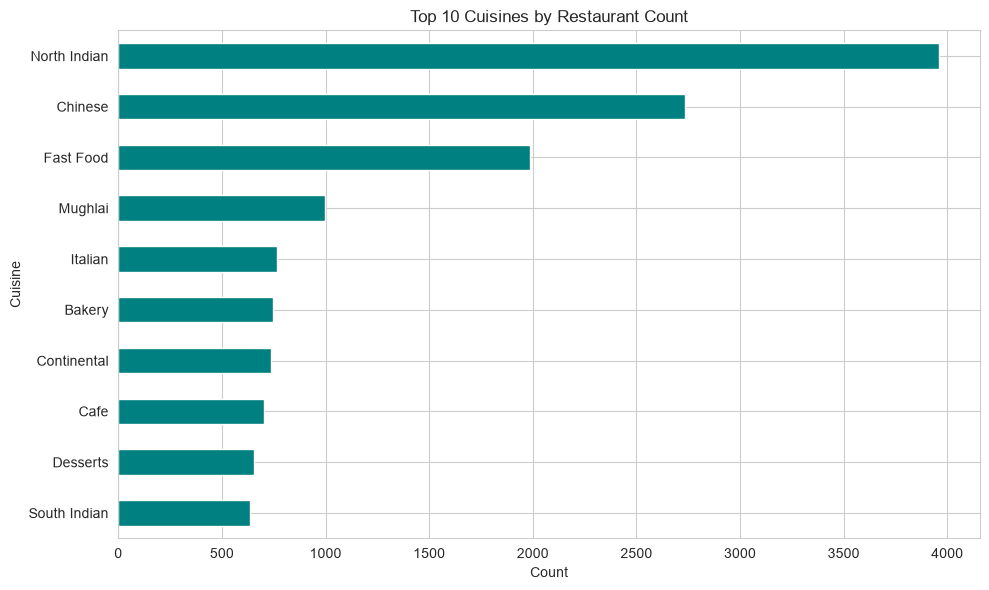

In [23]:
# Chart 1

plt.figure(figsize=(10, 6))
top_cuisines.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Cuisines by Restaurant Count')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

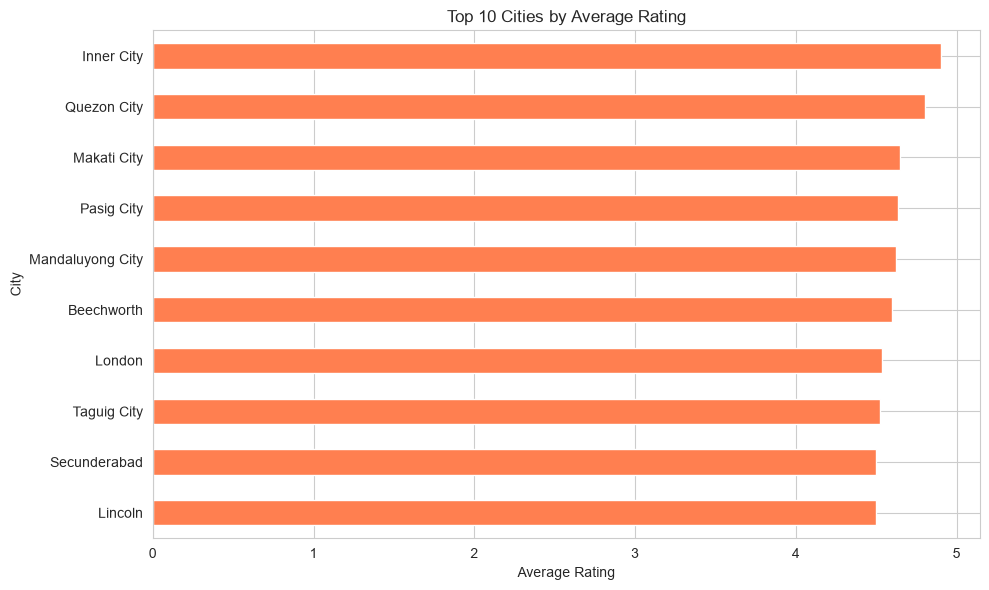

In [24]:
# Chart 2

plt.figure(figsize=(10, 6))
city_summary.head(10)['avg_rating'].sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Cities by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.tight_layout()
plt.show()

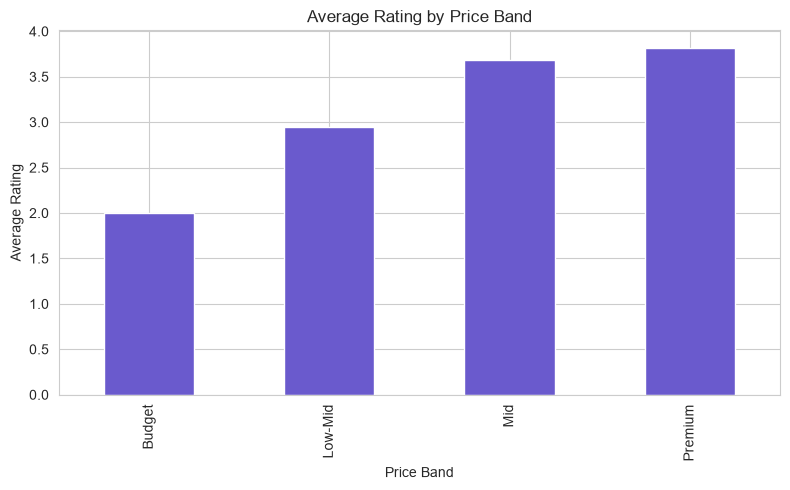

In [25]:
# Chart 3

plt.figure(figsize=(8, 5))
price_summary['avg_rating'].plot(kind='bar', color='slateblue')
plt.title('Average Rating by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

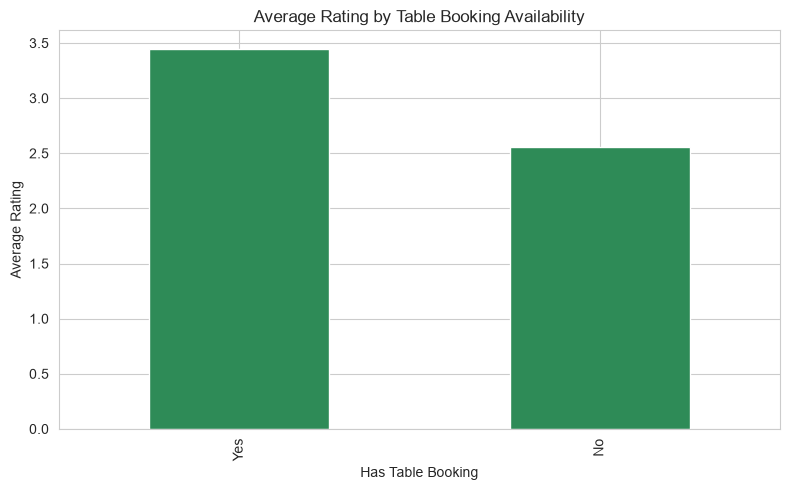

In [26]:
# Chart 4

plt.figure(figsize=(8, 5))
booking_summary['avg_rating'].plot(kind='bar', color='seagreen')
plt.title('Average Rating by Table Booking Availability')
plt.xlabel('Has Table Booking')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

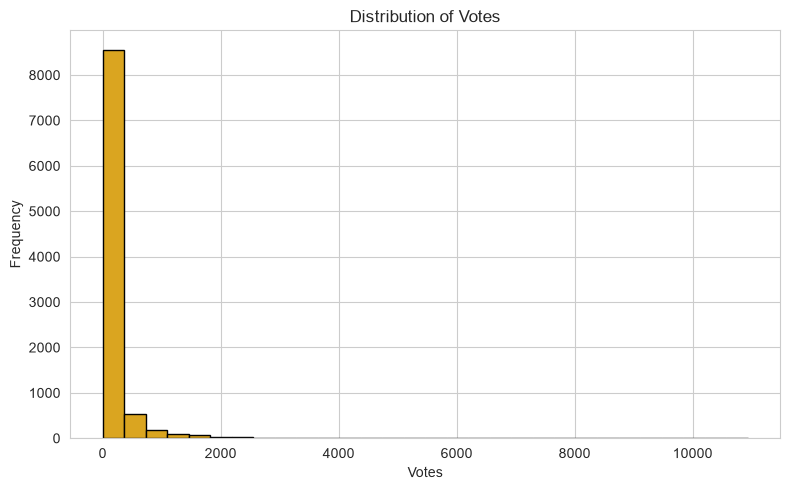

In [27]:
# Chart 5

plt.figure(figsize=(8, 5))
plt.hist(df['votes'], bins=30, color='goldenrod', edgecolor='black')
plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Key Insights
- Identify the highest-rated city.
- Identify the most common cuisine.
- Compare ratings across price bands.
- Check whether table booking or delivery relates to better ratings.
- Summarize what a restaurant owner could learn from the analysis.

## Conclusion
This analysis explored restaurant ratings, pricing, cuisine trends, and service features using Python, pandas, and NumPy. The findings can help understand which restaurant attributes are associated with better performance.